# **Optimal Policy for Car Rental Problem**


### **Assignment 3 - Reinforcement Learning - MSc. Computer Science, AUEB [2025-2026]**

> Maria Schoinaki, MSc Student
>
> Department of Informatics, Athens University of Economics and Business
>
> mar.schoinaki@aueb.gr

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from functools import wraps
from itertools import product

from scipy.stats import poisson

### Initialization


In [30]:
# ===========================================
#         Problem Configuration
# ===========================================

# We have two parking places.
# No place can hold more than 20 cars.
MAX_CARS = 20

# Tomorrow matters almost as much as today (90% as important).
DISCOUNT = 0.9

# We can move at most 5 cars during the night.
MOVE_LIMIT = 5

# Moving cars costs money.
MOVE_COST = 2

# Renting a car gives us 10 dollars.
RENT_REWARD = 10

# Poisson λ values:
# LAMBDA[0] = returns at location B
# LAMBDA[1] = requests at location A
# LAMBDA[2] = requests at location B
#
# Thinking of these like “how busy each place is”.
LAMBDA = [2, 3, 4]

### Poisson distribution

In [31]:
# =====================================================
#   STEP 1: PRECOMPUTE POISSON VALUES
#   (So the computer doesn't have to redo them 10000 times)
# =====================================================

def build_poisson_tables():
    """
    For each λ and each number of cars, we store:
    - the exact probability P(N = k)
    - the tail probability P(N >= k)

    This makes the algorithm much faster.
    """
    table = np.zeros((len(LAMBDA), MAX_CARS+1, 2))

    for idx, lam in enumerate(LAMBDA):
        for k in range(MAX_CARS+1):
            table[idx, k, 0] = poisson.pmf(k, lam)     # "exactly k cars"
            table[idx, k, 1] = poisson.sf(k-1, lam)    # "k or more cars"

    return table

poisson_table = build_poisson_tables()

### Rental Reward and Probability Distributions

In [32]:
# =====================================================
#   STEP 2: CALCULATE RENTAL REWARDS + NEXT-STATE PROBABILITIES
# =====================================================

def compute_rental_and_transitions():
    """
    We first move cars at night.
    After the move, we have (ss1, ss2) cars.

    Now:
      - Some customers come and rent cars.
      - Some cars come back later.

    This function computes:
      1. How much money we expect to earn today.
      2. Where we end up tomorrow (probability of each new number of cars).

    We do this ahead of time for all possible ss1, ss2.
    So later the algorithm can run very fast.
    """

    reward_matrix = np.zeros((MAX_CARS+1, MAX_CARS+1))
    transition_tensor = np.zeros(
        (MAX_CARS+1, MAX_CARS+1, MAX_CARS+1, MAX_CARS+1)
    )

    for ss1, ss2 in product(range(MAX_CARS+1), range(MAX_CARS+1)):

        # Try every possible number of rentals at both locations.
        for rqA in range(ss1+1):
            pA = poisson_table[1, rqA, int(rqA == ss1)]

            for rqB in range(ss2+1):
                pB = poisson_table[2, rqB, int(rqB == ss2)]

                p_rent = pA * pB
                rentals = rqA + rqB

                reward_matrix[ss1, ss2] += RENT_REWARD * rentals * p_rent

                # Maximum number of returns so that we don’t exceed 20 cars.
                max_retA = MAX_CARS + rqA - ss1
                max_retB = MAX_CARS + rqB - ss2

                # Try every possible number of returning cars.
                for rtA in range(max_retA):
                    pRetA = poisson_table[1, rtA, int(rtA == max_retA-1)]
                    for rtB in range(max_retB):
                        pRetB = poisson_table[0, rtB, int(rtB == max_retB-1)]

                        prob_event = p_rent * pRetA * pRetB

                        s1_new = ss1 - rqA + rtA
                        s2_new = ss2 - rqB + rtB

                        transition_tensor[s1_new, s2_new, ss1, ss2] += prob_event

    return reward_matrix, transition_tensor


# Precompute everything once
reward_after_move, transitions = compute_rental_and_transitions()

### Bellman Equation

In [33]:
# =====================================================
#   STEP 3: BELLMAN EQUATION FOR Q(s, a)
# =====================================================

def evaluate_action(s1, s2, move, values):
    """
    For a state (s1, s2) and an action 'move',
    compute how good this action is.

    The Bellman equation:

       Q(s,a) = reward + γ * expected future value - move cost
    """

    # Apply the move (but don't exceed 20 cars)
    ss1 = min(MAX_CARS, s1 - move)   # cars leaving A
    ss2 = min(MAX_CARS, s2 + move)   # cars entering B

    # Expected value of tomorrow
    expected_v = np.sum(values * transitions[:, :, ss1, ss2])

    return reward_after_move[ss1, ss2] + DISCOUNT * expected_v - MOVE_COST * abs(move)

### Policy Evaluation

In [34]:
# =====================================================
#   STEP 4: POLICY EVALUATION
# =====================================================

def policy_evaluation(policy, values, tol=1e-4):
    """
    We repeatedly update the value table until nothing changes very much.

    'Ask again and again how good the policy is,
     until the agent stops changing its mind.'
    """

    delta = float("inf")
    while delta > tol:
        delta = 0
        for s1, s2 in product(range(MAX_CARS+1), range(MAX_CARS+1)):
            old = values[s1, s2]
            move = policy[s1, s2]
            values[s1, s2] = evaluate_action(s1, s2, move, values)
            delta = max(delta, abs(old - values[s1, s2]))


In [35]:
# =====================================================
#   STEP 5: POLICY IMPROVEMENT
# =====================================================

def policy_improvement(policy, values):
    """
    For every state, we ask:
    'If we try all possible actions, which one is best?'

    If the best action changes the old policy, we are not done yet.
    """

    stable = True

    for s1, s2 in product(range(MAX_CARS+1), range(MAX_CARS+1)):

        old_action = policy[s1, s2]

        # What actions can we take? (limited by how many cars I have)
        lo = -min(s2, MOVE_LIMIT)
        hi = min(s1, MOVE_LIMIT)
        valid_actions = range(lo, hi+1)

        # Evaluate each possible move
        qvals = [evaluate_action(s1, s2, a, values) for a in valid_actions]
        best_move = valid_actions[np.argmax(qvals)]

        policy[s1, s2] = best_move

        if best_move != old_action:
            stable = False

    return stable

### Policy Iteration

In [36]:
# =====================================================
#   STEP 6: RUN POLICY ITERATION
# =====================================================

values = np.zeros((MAX_CARS+1, MAX_CARS+1))
policy = np.zeros((MAX_CARS+1, MAX_CARS+1), dtype=int)

done = False
while not done:
    policy_evaluation(policy, values)
    done = policy_improvement(policy, values)

print("Policy iteration finished!")

Policy iteration finished!


### Results

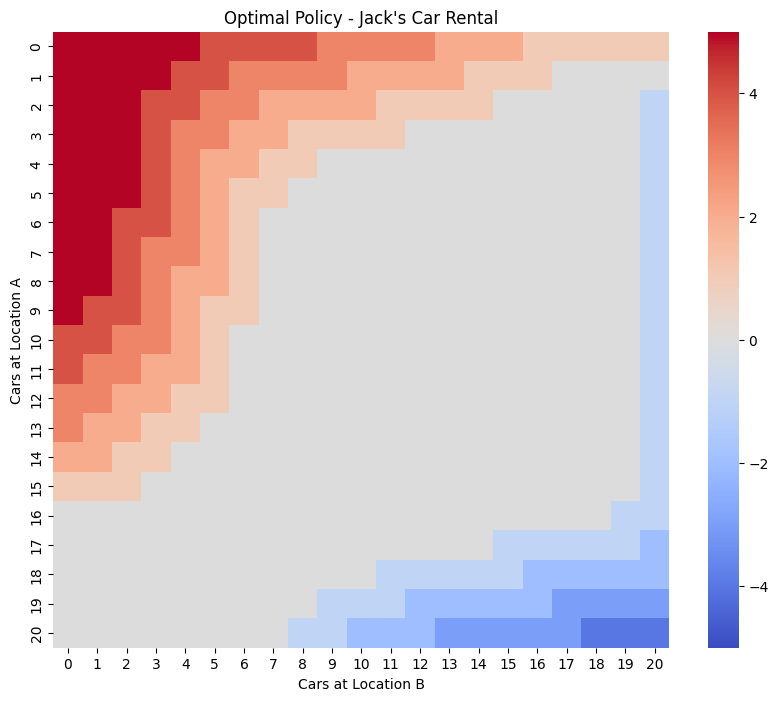

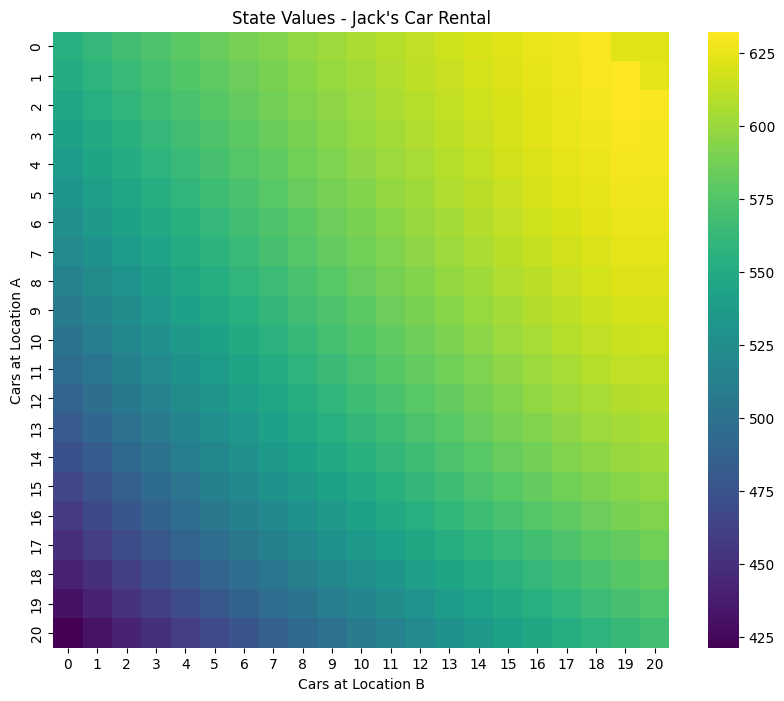

In [37]:
# =====================================================
#   STEP 7: VISUALIZE RESULTS
# =====================================================

df_pol = pd.DataFrame(policy[::-1])
df_val = pd.DataFrame(values[::-1])

plt.figure(figsize=(10, 8))
sns.heatmap(df_pol, cmap="coolwarm", vmin=-MOVE_LIMIT, vmax=MOVE_LIMIT, square=True)
plt.title("Optimal Policy - Jack's Car Rental")
plt.xlabel("Cars at Location B")
plt.ylabel("Cars at Location A")
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(df_val, cmap="viridis", square=True)
plt.title("State Values - Jack's Car Rental")
plt.xlabel("Cars at Location B")
plt.ylabel("Cars at Location A")
plt.show()


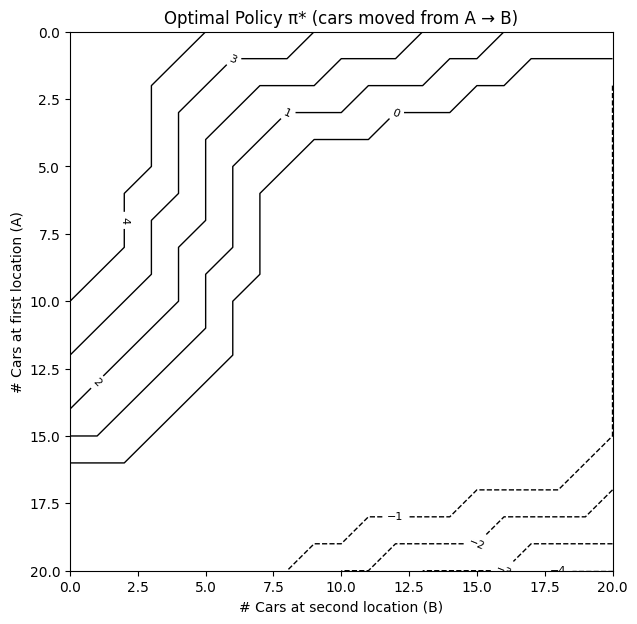

In [38]:
import matplotlib.pyplot as plt
import numpy as np

# We want axes: x = cars at B, y = cars at A (0..20)
x = np.arange(policy.shape[1])
y = np.arange(policy.shape[0])

X, Y = np.meshgrid(x, y)

plt.figure(figsize=(7, 7))

# Note: policy is indexed [A, B], but we want y increasing upwards in the plot
# So we flip vertically for display
policy_display = policy[::-1, :]

levels = np.arange(-5, 6, 1)

cs = plt.contour(
    X, Y, policy_display,
    levels=levels,
    linewidths=1.0,
    colors='black'
)

plt.clabel(cs, inline=True, fontsize=8)  # draw numbers on contours

plt.xlabel('# Cars at second location (B)')
plt.ylabel('# Cars at first location (A)')
plt.title('Optimal Policy π* (cars moved from A → B)')
plt.gca().invert_yaxis()
plt.grid(False)
plt.show()
